In [1]:
import os, ROOT as r
base = os.path.expandvars("$HOME/roohill/standalone")
r.gInterpreter.AddIncludePath(os.path.join(base, "include"))
r.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
FILES = ["root://eoslhcb.cern.ch//eos/lhcb/grid/prod/lhcb/anaprod/lhcb/LHCb/Collision25/BD2DPI.ROOT/00316717/0000/00316717_00000007_1.bd2dpi.root"] 
TREE_PATH = "Tuple_Bd2DPi/DecayTree"


Welcome to JupyROOT 6.30/02



# Previous file, inital fit, ignore for now

Custom PDFs loaded: True True

[build] applying Dπ cuts and skimming...



Reading tuples: 12it [00:29,  2.42s/it]



[build] done in 29.1s — kept 7121538 events

[sidebands] fitting comb-only in LSB+RSB...

[prefit] signal+comb (tails frozen)...

[fit] final binned extended likelihood, NBINS = 600
[fit] time: 5.7s, status=3, covQual=2



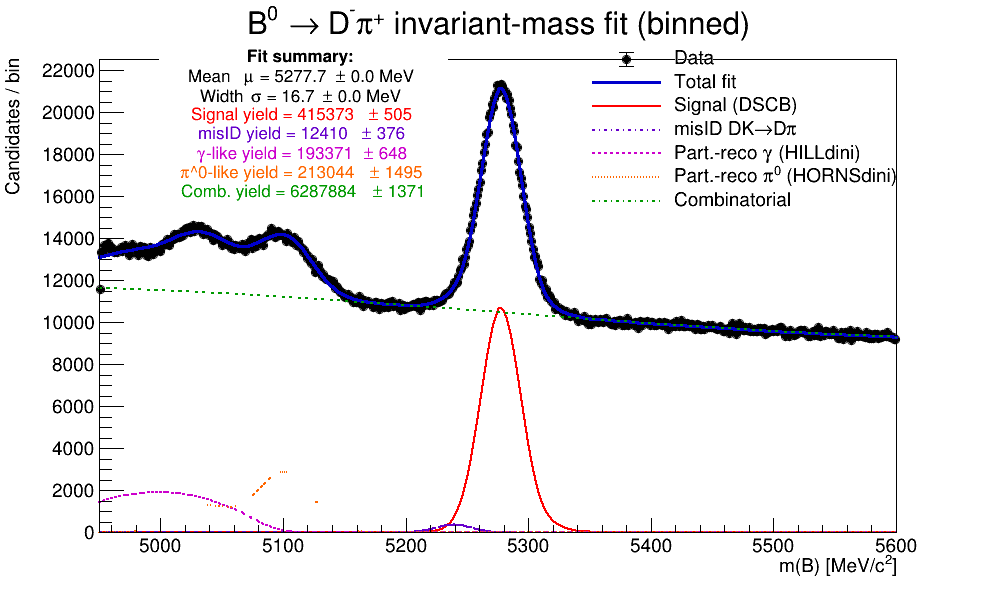


[top correlations]

NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
1] INFO:NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
] INFO[#:NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int1(] INFOm:)
NumericIntegration -- RooRealIntegral::init(BKG_g_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
PID1144041/RooRealMPFE::nll_pdf_dh_19325090_MPFE0[ arg=nll_pdf_dh_GOF0 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,c0,c1,c2,dHb,dMis,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,r_a,r_csi,r_fs,r_rs,r_shift,r_sigma,sig,sig_mis) ]

PID1144246/RooRealMPFE::nll_pdf_dh_19325090_MPFE7[ arg=nll_pdf_dh_GOF7 vars=(Ncomb,Ng,Nmis,Npi,Nsig,aL,aR,c0,c1,c2,dHb,dMis,dRb,fLR,h_a,h_csi,h_fs,h_rs,h_shift,h_sigma,mu,nL,nR,r_a,r_csi,r_fs,r_rs,r_shift,r_sigma,sig,sig_mis) ]



Info in <TCanvas::Print>: png file /tmp/fit_1762363969.png has been created



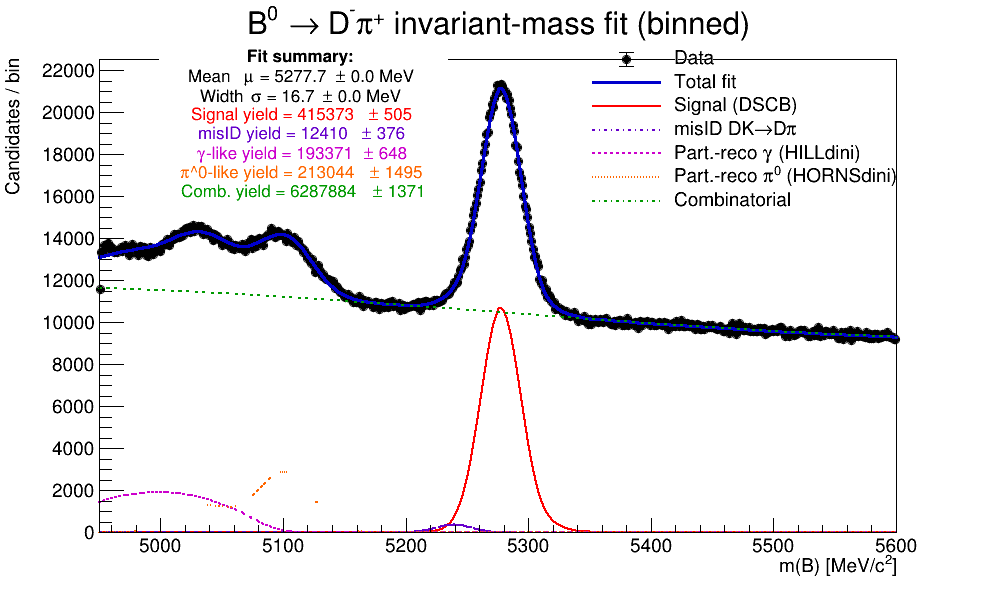

In [2]:
# -*- coding: utf-8 -*-
# Robust binned fit for B0 -> D- pi+ with sideband-constrained comb, prefit seeding, and safer minimization

import os, glob, time, numpy as np, uproot, ROOT
from ROOT import RooFit as RF
from IPython.display import Image as IPyImage, display as ipydisplay

# -----------------------------
# Config
# -----------------------------
# Point FILES to your tuples (wildcard OK)
  # <-- adjust to your paths

TREE_PATH  = "Tuple_Bd2DPi/DecayTree"
USE_SUBSET = False          # <= toggle subset for speed
SUBSET_N   = 25_000         # how many events max to use
NBINS      = 600            # finer binning for ~16 MeV core width
COMB_MODEL = "cheby"        # "cheby" or "expo"

D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
BACHELOR_PIDK_MAX = 0.0     # pion-like bachelor
M_PI, M_K = 139.57039, 493.677
mmin, mmax = 4950., 5600.

# ROOT housekeeping
ROOT.gROOT.SetBatch(True)
ROOT.EnableImplicitMT()
base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs loaded:", hasattr(ROOT,"RooHILLdini"), hasattr(ROOT,"RooHORNSdini"))

# -----------------------------
# Helpers
# -----------------------------
def build_masses(arr):
    """Recompute B mass under π/K bachelor hypotheses."""
    pD, thD, phD = arr["lab2_P"], arr["lab2_THETA"], arr["lab2_PHI"]
    mD = arr["lab2_MASS"]
    pB, thB, phB = arr["lab1_P"], arr["lab1_THETA"], arr["lab1_PHI"]
    s, c = np.sin, np.cos
    pxD = pD*s(thD)*c(phD); pyD = pD*s(thD)*s(phD); pzD = pD*c(thD)
    pxB = pB*s(thB)*c(phB); pyB = pB*s(thB)*s(phB); pzB = pB*c(thB)
    ED  = np.sqrt(pD**2 + mD**2)
    Epi = np.sqrt(pB**2 + M_PI**2)
    EK  = np.sqrt(pB**2 + M_K**2)
    px, py, pz = pxD+pxB, pyD+pyB, pzD+pzB
    p2 = px**2 + py**2 + pz**2
    mB_pi = np.sqrt(np.maximum((ED + Epi)**2 - p2, 0))
    mB_K  = np.sqrt(np.maximum((ED + EK )**2 - p2, 0))
    return mB_pi, mB_K

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw): return it

# -----------------------------
# Build Dπ sample (optionally reduced)
# -----------------------------
assert FILES, "FILES is empty — point FILES to your ROOT files."

vals_all = []

branches = [
    "lab0_MASS","lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS","lab1_PIDK",
    "lab2_P","lab2_THETA","lab2_PHI","lab1_P","lab1_THETA","lab1_PHI"
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print("\n[build] applying Dπ cuts and skimming...")
for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=True),
    desc="Reading tuples"
):
    finite = np.isfinite(arrays["lab0_MASS"]) & np.isfinite(arrays["lab0_END_VCHI2DOF"]) \
           & np.isfinite(arrays["lab2_END_VCHI2DOF"]) & np.isfinite(arrays["lab2_MASS"]) \
           & np.isfinite(arrays["lab1_PIDK"]) & np.isfinite(arrays["lab2_P"]) \
           & np.isfinite(arrays["lab2_THETA"]) & np.isfinite(arrays["lab2_PHI"]) \
           & np.isfinite(arrays["lab1_P"]) & np.isfinite(arrays["lab1_THETA"]) \
           & np.isfinite(arrays["lab1_PHI"])

    sel = (finite
           & (arrays["lab1_PIDK"] < BACHELOR_PIDK_MAX)
           & (arrays["lab0_END_VCHI2DOF"] < B_END_VCHI2DOF_MAX)
           & (arrays["lab2_END_VCHI2DOF"] < D_END_VCHI2DOF_MAX)
           & (np.abs(arrays["lab2_MASS"] - D_MASS) < D_WINDOW))

    mB_pi, _ = build_masses(arrays)
    v = mB_pi[sel]
    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need: break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build] done in {time.time()-t0:.1f}s — kept {vals.size} events")
assert vals.size > 0, "No events after cuts/subset."

# -----------------------------
# Make binned RooDataHist
# -----------------------------
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

# Seed comb slope sign from a simple low-mass regression
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]  # slope sign
else:
    coef = 0.0

# Build binned hist for fit
hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("h","h", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dh","binned Dpi", ROOT.RooArgList(m), dhist)

# -----------------------------
# Quick data-driven seeds for mu and sigma
# -----------------------------
focus = vals[(vals>5230)&(vals<5330)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5230,5330))
    edges = np.linspace(5230,5330,81)
    xmid  = 0.5*(edges[1:]+edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# -----------------------------
# Physics model
# -----------------------------
# --- Signal: DSCB (two CBs sharing mu,sig) ---
mu  = ROOT.RooRealVar("mu","mean", mu0, mu0-30., mu0+30.)
sig = ROOT.RooRealVar("sig","sigma", sig0, 8., 30.)

# left tail (αL > 0)
aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB",  m, mu, sig, aL, nL)
# right tail (αR < 0)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG   = ROOT.RooAddPdf("SIG","DSCB", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# --- Mis-ID DK->Dπ peaking background (reconstructed with π hypothesis) ---
dMis   = ROOT.RooRealVar("dMis","DK->Dpi shift",45,35,55)  # tighter range
mu_mis = ROOT.RooFormulaVar("mu_mis","@0-@1", ROOT.RooArgList(mu,dMis))
sig_mis= ROOT.RooRealVar("sig_mis","misID width",max(14.0,min(20.0,sig0+2.)),12,28)
MIS    = ROOT.RooGaussian("MIS","misID DK->Dpi", m, mu_mis, sig_mis)

# --- Partially reconstructed backgrounds: HILLdini (γ-like) and HORNSdini (π0-like) ---
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# --- Combinatorial: Cheby(2) or Exponential ---
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope", -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# -----------------------------
# Extended yields (start from histogram integrals)
# -----------------------------
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","signal yield", 0.15*Ntot, 0.0, 2.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","misID yield",  0.01*Ntot, 0.0, 0.25*Ntot)    # allow larger if needed
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",  0.04*Ntot, 0.0, 1.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",    0.01*Ntot, 0.0, 1.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",  0.75*Ntot, 0.0, 2.0*Ntot)

# -----------------------------
# Sideband training of combinatorial + constraints
# -----------------------------
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5450, 5600)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

# Build weak Gaussian constraints around the sideband result (30% rel. width or floor)
def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

# Optional: weak priors on partially-reco yields (stabilizers)
mu_Ng,  sig_Ng  = 0.03*Ntot, max(1.0, 0.03*Ntot)
mu_Npi, sig_Npi = 0.01*Ntot, max(1.0, 0.01*Ntot)
gNg  = ROOT.RooGaussian("gNg","weak prior Ng",  Ng,  RF.RooConst(mu_Ng),  RF.RooConst(sig_Ng))
gNpi = ROOT.RooGaussian("gNpi","weak prior Npi", Npi, RF.RooConst(mu_Npi), RF.RooConst(sig_Npi))
constraints.addOwned(gNg); constraints.addOwned(gNpi)

# -----------------------------
# Prefit: signal + comb only with frozen tails (stabilizes μ,σ and Ncomb)
# -----------------------------
for v in (aL,nL,aR,nR,fLR):
    v.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre","pre", ROOT.RooArgList(SIG,BKG_comb),
                         ROOT.RooArgList(Nsig,Ncomb))
print("\n[prefit] signal+comb (tails frozen)...")
_ = pdf_pre.fitTo(dh,
                  RF.Extended(True),
                  RF.ExternalConstraints(constraints),
                  RF.NumCPU(4),
                  RF.Offset(True),
                  RF.Minimizer("Minuit2","Migrad"),
                  RF.PrintLevel(-1))

for v in (aL,nL,aR,nR,fLR):
    v.setConstant(False)

# -----------------------------
# Full model and final fit
# -----------------------------
pdf = ROOT.RooAddPdf("pdf","Dpi model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

print("\n[fit] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(dh,
                   RF.Extended(True),
                   RF.ExternalConstraints(constraints),
                   RF.NumCPU(8),
                   RF.Offset(True),
                   RF.Strategy(2),
                   RF.Minimizer("Minuit2","Migrad"),
                   RF.Save(True),
                   RF.PrintLevel(-1))
# Optional: HESSE polish
_ = pdf.fitTo(dh,
              RF.Extended(True),
              RF.ExternalConstraints(constraints),
              RF.NumCPU(8),
              RF.Offset(True),
              RF.Strategy(2),
              RF.Minimizer("Minuit2","Hesse"),
              RF.Save(True),
              RF.PrintLevel(-1))

print(f"[fit] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")

# -----------------------------
# Plot
# -----------------------------
frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} invariant-mass fit (binned)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_{int(time.time())}","DpiFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

# Legend
leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                 "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",            "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal (DSCB)",               "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID DK#rightarrowD#pi",     "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)","l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",               "l")
leg.Draw()

# Summary box
box = ROOT.TPaveText(0.16, 0.66, 0.45, 0.92, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.1f} MeV")
t = box.AddText(f"Signal yield = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"misID yield = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like yield = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like yield = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. yield = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_{int(time.time())}.png"; c.SaveAs(tmp_png)
ipydisplay(IPyImage(filename=tmp_png))

# -----------------------------
# Optional: print top correlations to diagnose leftovers
# -----------------------------
try:
    corr = fitres.correlationMatrix()
    print("\n[top correlations]")
    names = [corr.GetRowName(i) for i in range(corr.GetNrows())]
    pairs = []
    for i in range(corr.GetNrows()):
        for j in range(i+1, corr.GetNcols()):
            pairs.append((abs(corr[i][j]), names[i], names[j], corr[i][j]))
    pairs.sort(reverse=True)
    for k in range(min(10, len(pairs))):
        a, n1, n2, v = pairs[k]
        print(f"{n1:>12s}–{n2:<12s}: {v:+.3f}")
except Exception as _e:
    pass


# XG FILE, 
### run numbers used s24c4 MagUp,runs 308104 - 308540
### s24c4 MagDown, complete: runs 307589 - 308098

In [4]:
import glob, uproot

files = sorted(
    glob.glob("/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_up*_final.root")
  + glob.glob("/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_down*_final.root")
)
print("N files:", len(files))
print(files[:3])

with uproot.open(files[0]) as f:
    print(f.keys())   # see what the tree is actually called


N files: 2
['/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_down_final.root', '/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_up_final.root']
['Tuple;1', 'Tuple/DecayTree;1']



In [7]:
import uproot
import glob

# -----------------------------
# Point to your files and tree
# -----------------------------
FILES = sorted(
    glob.glob("/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_*_final.root")
)
assert FILES, "No ROOT files found at given path."

TREE_PATH = "Tuple/DecayTree"   # from your earlier check

# -----------------------------
# Open the first file and list branches
# -----------------------------
first_file = FILES[0]
print(f"\nInspecting: {first_file}")

with uproot.open(first_file) as f:
    tree = f[TREE_PATH]
    print(f"Tree name: {TREE_PATH}")
    print(f"Number of entries: {tree.num_entries:,}")
    print("\n--- Branch names ---\n")

    branches = list(tree.keys())
    for i, name in enumerate(branches, 1):
        print(f"{i:4d}: {name}")

# -----------------------------
# Optionally: write to a text file
# -----------------------------
OUTFILE = "branches_list.txt"
with open(OUTFILE, "w") as fout:
    for name in branches:
        fout.write(name + "\n")

print(f"\nTotal branches: {len(branches)}")
print(f"Saved full list to: {OUTFILE}")



Inspecting: /eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_down_final.root
Tree name: Tuple/DecayTree
Number of entries: 2,973,485

--- Branch names ---

   1: EVENTNUMBER
   2: Hlt1TrackMVADecision
   3: Hlt1TwoTrackMVADecision
   4: Hlt1_TCK
   5: Hlt2B2OC_BdToDmPi_DmToPimPimKpDecision
   6: Hlt2Topo2BodyDecision
   7: Hlt2Topo3BodyDecision
   8: Hlt2_TCK
   9: RUNNUMBER
  10: lab0_BPVCHI2DOF
  11: lab0_BPVDIRA
  12: lab0_BPVFD
  13: lab0_BPVFDCHI2
  14: lab0_BPVIP
  15: lab0_BPVIPCHI2
  16: lab0_BPVLTIME
  17: lab0_BPVX
  18: lab0_BPVY
  19: lab0_BPVZ
  20: lab0_CHI2DOF
  21: lab0_CHILD1_FDCHI2wrtSV
  22: lab0_CHILD1_FDwrtSV
  23: lab0_CHILD1_IPCHI2wrtSV
  24: lab0_CHILD1_IPwrtSV
  25: lab0_DTF_LifetimeFit_CHI2DOF
  26: lab0_DTF_LifetimeFit_CTAU
  27: lab0_DTF_LifetimeFit_CTAUERR
  28: lab0_DTF_LifetimeFit_MASS
  29: lab0_DTF_MassFitConsD_CHI2DOF
  30: lab0_DTF_MassFitConsD_MASS
  31: lab0_DTF_MassFitConsD_P
  32: lab0_END_VCHI2DOF
  33: lab0_END_VX
  34: lab0_END

## cuts analysis


[build] reading mass + XG arrays and applying basic cuts...
[build] done in 69.1s, kept 8637418 events (before B mass window)
  m(B) range: 4950.0 – 6000.0
  XG   range: 0.5000 – 1.0000
[build] after B mass window 4950.0-5600.0: 8396940 events
[mass regions] signal_proxy: 2749730 events, background_proxy: 4527495 events

[scan] scanning XG thresholds...
XG > 0.5794: eps_S=0.972, R_B=0.062, J=0.034
XG > 0.5880: eps_S=0.969, R_B=0.068, J=0.036
XG > 0.5965: eps_S=0.965, R_B=0.074, J=0.039
XG > 0.6051: eps_S=0.962, R_B=0.079, J=0.042
XG > 0.6137: eps_S=0.959, R_B=0.085, J=0.044
XG > 0.6223: eps_S=0.956, R_B=0.090, J=0.046
XG > 0.6309: eps_S=0.953, R_B=0.096, J=0.048
XG > 0.6394: eps_S=0.950, R_B=0.101, J=0.050
XG > 0.6480: eps_S=0.946, R_B=0.106, J=0.052
XG > 0.6566: eps_S=0.943, R_B=0.112, J=0.055
XG > 0.6652: eps_S=0.940, R_B=0.117, J=0.056
XG > 0.6738: eps_S=0.936, R_B=0.122, J=0.058
XG > 0.6823: eps_S=0.933, R_B=0.127, J=0.060
XG > 0.6909: eps_S=0.929, R_B=0.133, J=0.062
XG > 0.6995: 

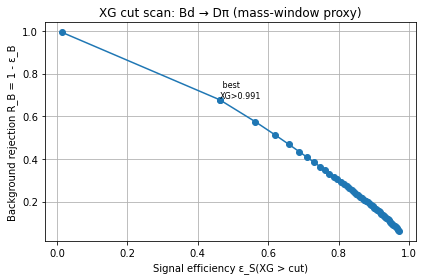

In [8]:
# -*- coding: utf-8 -*-
"""
Find best XG cut for Bd -> D- pi+ using data only (no fits).

- Uses lab0_MASS as B mass.
- Uses BDTGResponse_XGB_1 as "XG" classifier.
- Applies basic Bd->Dpi-like cuts using existing branches.
- Defines signal/background by B mass windows.
- Scans XG > cut, computes signal efficiency & background rejection.
- Chooses best cut by maximizing Youden's J = eps_S + R_B - 1.
"""

import glob, time
import numpy as np
import uproot
import matplotlib.pyplot as plt

# -----------------------------
# File + tree
# -----------------------------
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_up_final.root",
]
for f in FILES:
    assert glob.glob(f), f"File not found: {f}"

TREE_PATH = "Tuple/DecayTree"

# -----------------------------
# Global config
# -----------------------------
USE_SUBSET   = False      # set True for a quick test
SUBSET_N     = 300_000    # max events if subset

# B mass range to consider
mmin, mmax   = 4950., 5600.

# B0 peak & regions (tune if needed)
B0_MASS      = 5279.65    # MeV
SIG_WIN      = 25.0       # |m - B0_MASS| < SIG_WIN => signal proxy
BKG_L_MAX    = 5200.0     # left sideband:  [mmin, BKG_L_MAX]
BKG_R_MIN    = 5360.0     # right sideband: [BKG_R_MIN, mmax]

# D mass window
D_MASS       = 1869.65    # MeV
D_WINDOW     = 30.0       # |M(D) - D_MASS| < D_WINDOW

# Basic cuts
B_VCHI2_MAX     = 7.0
D_VCHI2_MAX     = 7.0
BACH_PIDK_MAX   = 0.0     # pion-like bachelor

# -----------------------------
# Branch names (from your listing)
# -----------------------------
BR_MASS        = "lab0_MASS"           # B mass
BR_XG          = "BDTGResponse_XGB_1"  # XG classifier
BR_RUN         = "RUNNUMBER"           # run number (not used here but available)

BR_B_VCHI2     = "lab0_END_VCHI2DOF"   # B vertex χ²/ndof
BR_D_VCHI2     = "lab2_END_VCHI2DOF"   # D vertex χ²/ndof
BR_BACH_PIDK   = "lab1_PIDK"           # bachelor PIDK
BR_D_MASS      = "lab2_MASS"           # D mass

# -----------------------------
# Build arrays: m(B) and XG
# -----------------------------
branches = [
    BR_MASS,
    BR_XG,
    BR_B_VCHI2,
    BR_D_VCHI2,
    BR_BACH_PIDK,
    BR_D_MASS,
]

vals_all = []
xg_all   = []

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()

print("\n[build] reading mass + XG arrays and applying basic cuts...")
for arrays in uproot.iterate(
    [f"{fp}:{TREE_PATH}" for fp in FILES],
    expressions=branches,
    step_size="50 MB",
    library="np",
    allow_missing=False,   # crash if any branch name is wrong
):
    mB   = arrays[BR_MASS]
    XG   = arrays[BR_XG]
    bchi = arrays[BR_B_VCHI2]
    dchi = arrays[BR_D_VCHI2]
    pidk = arrays[BR_BACH_PIDK]
    mD   = arrays[BR_D_MASS]

    # basic finiteness
    finite = (
        np.isfinite(mB) &
        np.isfinite(XG) &
        np.isfinite(bchi) &
        np.isfinite(dchi) &
        np.isfinite(pidk) &
        np.isfinite(mD)
    )

    # physics-like cuts
    sel = (
        finite &
        (bchi < B_VCHI2_MAX) &
        (dchi < D_VCHI2_MAX) &
        (pidk < BACH_PIDK_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW)
    )

    mB = mB[sel]
    XG = XG[sel]

    if USE_SUBSET and got < need:
        nleft = int(max(0, need - got))
        mB = mB[:nleft]
        XG = XG[:nleft]

    vals_all.append(mB)
    xg_all.append(XG)
    got += mB.size
    if got >= need:
        break

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
xg   = np.concatenate(xg_all)   if xg_all   else np.array([], dtype=float)

print(f"[build] done in {time.time()-t0:.1f}s, kept {vals.size} events (before B mass window)")
if vals.size == 0:
    raise RuntimeError("0 events – check cuts or branch names.")

print(f"  m(B) range: {vals.min():.1f} – {vals.max():.1f}")
print(f"  XG   range: {xg.min():.4f} – {xg.max():.4f}")

# restrict to global B mass window
mask_m = (vals > mmin) & (vals < mmax)
vals = vals[mask_m]
xg   = xg[mask_m]
print(f"[build] after B mass window {mmin}-{mmax}: {vals.size} events")

# -----------------------------
# Define signal & background regions (no fits, just mass windows)
# -----------------------------
sig_mask = np.abs(vals - B0_MASS) < SIG_WIN
bkg_mask = ((vals >= mmin) & (vals <= BKG_L_MAX)) | ((vals >= BKG_R_MIN) & (vals <= mmax))

xg_sig = xg[sig_mask]
xg_bkg = xg[bkg_mask]

print(f"[mass regions] signal_proxy: {xg_sig.size} events, "
      f"background_proxy: {xg_bkg.size} events")

if xg_sig.size == 0 or xg_bkg.size == 0:
    raise RuntimeError("Signal or background proxy is empty; tweak SIG_WIN / sidebands.")

# -----------------------------
# Scan XG thresholds, compute ε_S, R_B, and Youden's J
# -----------------------------
print("\n[scan] scanning XG thresholds...")

xg_min = np.percentile(xg, 5)
xg_max = np.percentile(xg, 99)
thresholds = np.linspace(xg_min, xg_max, 50)

eff_s  = []
rej_b  = []
youden = []

for thr in thresholds:
    s_pass = np.sum(xg_sig > thr)
    b_pass = np.sum(xg_bkg > thr)
    s_tot  = xg_sig.size
    b_tot  = xg_bkg.size

    eps_s = s_pass / s_tot if s_tot > 0 else 0.0   # signal efficiency
    eps_b = b_pass / b_tot if b_tot > 0 else 0.0   # background efficiency
    R_b   = 1.0 - eps_b                            # background rejection
    J     = eps_s + R_b - 1.0                      # Youden's J

    eff_s.append(eps_s)
    rej_b.append(R_b)
    youden.append(J)

    print(f"XG > {thr:.4f}: eps_S={eps_s:.3f}, R_B={R_b:.3f}, J={J:.3f}")

eff_s  = np.array(eff_s)
rej_b  = np.array(rej_b)
youden = np.array(youden)

best_idx   = np.argmax(youden)
best_thr   = thresholds[best_idx]
best_eps_s = eff_s[best_idx]
best_R_b   = rej_b[best_idx]
best_J     = youden[best_idx]

print("\n[best cut]")
print(f"  XG > {best_thr:.4f}")
print(f"  signal efficiency   ε_S = {best_eps_s:.3f}")
print(f"  background rejection R_B = {best_R_b:.3f}")
print(f"  Youden's J          J   = {best_J:.3f}")

# -----------------------------
# Plot ROC curve
# -----------------------------
plt.figure()
plt.plot(eff_s, rej_b, marker="o")
plt.scatter([best_eps_s], [best_R_b])
plt.text(best_eps_s, best_R_b,
         f" best\nXG>{best_thr:.3f}",
         fontsize=8, ha="left", va="bottom")

plt.xlabel("Signal efficiency ε_S(XG > cut)")
plt.ylabel("Background rejection R_B = 1 - ε_B")
plt.title("XG cut scan: Bd → Dπ (mass-window proxy)")
plt.grid(True)
plt.tight_layout()
plt.show()



[build] reading vertices for χ² plots...
[done] read 200000 events in 1.1s
Signal proxy events: 60181, background proxy: 105052



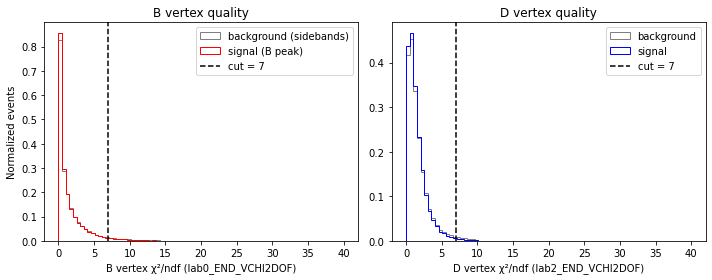

In [9]:


# B and D branches
BR_B_MASS  = "lab0_MASS"
BR_D_MASS  = "lab2_MASS"
BR_B_VCHI2 = "lab0_END_VCHI2DOF"
BR_D_VCHI2 = "lab2_END_VCHI2DOF"

# physics constants
B0_MASS = 5279.65
SIG_WIN = 25.0
BKG_L_MAX = 5200.0
BKG_R_MIN = 5360.0
mmin, mmax = 4950., 5600.
D_MASS = 1869.65
D_WINDOW = 30.0

USE_SUBSET = True
SUBSET_N = 200_000

# -----------------------------
# Read branches
# -----------------------------
branches = [BR_B_MASS, BR_D_MASS, BR_B_VCHI2, BR_D_VCHI2]

vals_B = []
vals_D = []
masses = []

need = SUBSET_N if USE_SUBSET else float("inf")
got = 0
t0 = time.time()

print("\n[build] reading vertices for χ² plots...")
for arrays in uproot.iterate(
    [f"{fp}:{TREE_PATH}" for fp in FILES],
    expressions=branches,
    step_size="50 MB",
    library="np",
):
    mB = arrays[BR_B_MASS]
    mD = arrays[BR_D_MASS]
    vB = arrays[BR_B_VCHI2]
    vD = arrays[BR_D_VCHI2]

    finite = (
        np.isfinite(mB)
        & np.isfinite(mD)
        & np.isfinite(vB)
        & np.isfinite(vD)
        & (np.abs(mD - D_MASS) < D_WINDOW)  # loose D mass window
    )

    mB = mB[finite]
    vB = vB[finite]
    vD = vD[finite]

    if USE_SUBSET and got < need:
        nleft = int(max(0, need - got))
        mB = mB[:nleft]
        vB = vB[:nleft]
        vD = vD[:nleft]

    vals_B.append(vB)
    vals_D.append(vD)
    masses.append(mB)
    got += mB.size
    if got >= need:
        break

mB_all = np.concatenate(masses)
vB_all = np.concatenate(vals_B)
vD_all = np.concatenate(vals_D)

print(f"[done] read {mB_all.size} events in {time.time()-t0:.1f}s")

# -----------------------------
# Split into signal and background
# -----------------------------
sig_mask = np.abs(mB_all - B0_MASS) < SIG_WIN
bkg_mask = ((mB_all > mmin) & (mB_all < BKG_L_MAX)) | ((mB_all > BKG_R_MIN) & (mB_all < mmax))

vB_sig, vB_bkg = vB_all[sig_mask], vB_all[bkg_mask]
vD_sig, vD_bkg = vD_all[sig_mask], vD_all[bkg_mask]

print(f"Signal proxy events: {vB_sig.size}, background proxy: {vB_bkg.size}")

# -----------------------------
# Plot histograms
# -----------------------------
plt.figure(figsize=(10,4))
bins = np.linspace(0, 40, 80)

plt.subplot(1,2,1)
plt.hist(vB_bkg, bins=bins, histtype="step", color="gray", label="background (sidebands)", density=True)
plt.hist(vB_sig, bins=bins, histtype="step", color="red", label="signal (B peak)", density=True)
plt.axvline(7, color="black", ls="--", lw=1.5, label="cut = 7")
plt.xlabel("B vertex χ²/ndf (lab0_END_VCHI2DOF)")
plt.ylabel("Normalized events")
plt.title("B vertex quality")
plt.legend()

plt.subplot(1,2,2)
plt.hist(vD_bkg, bins=bins, histtype="step", color="gray", label="background", density=True)
plt.hist(vD_sig, bins=bins, histtype="step", color="blue", label="signal", density=True)
plt.axvline(7, color="black", ls="--", lw=1.5, label="cut = 7")
plt.xlabel("D vertex χ²/ndf (lab2_END_VCHI2DOF)")
plt.title("D vertex quality")
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
import os
import numpy as np
import uproot
from tqdm import tqdm

# -----------------------------
# Config
# -----------------------------
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_up_final.root",
]
assert all(os.path.exists(f) for f in FILES), "One or more FILES do not exist."

TREE_PATH = "Tuple/DecayTree"

# s24c4 lumi ranges (runNumber)
RUN_UP_MIN,   RUN_UP_MAX   = 308104, 308540
RUN_DOWN_MIN, RUN_DOWN_MAX = 307589, 308098

# XG (BDT) cut – set to None to ignore
XG_BRANCH = "BDTGResponse_XGB_1"
XG_CUT    = 0.991     # or None

# use only a subset for speed
USE_SUBSET = False
SUBSET_N   = 500_000

# -----------------------------
# Scan runs
# -----------------------------
branches = ["runNumber", "RUNNUMBER", XG_BRANCH]

all_run_lower = []
all_run_upper = []
all_run_sel   = []

t0 = 0.0
print("\n[check] scanning run numbers...")
need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0

for arrays in tqdm(
    uproot.iterate(
        [f"{fp}:{TREE_PATH}" for fp in FILES],
        expressions=branches,
        step_size="60 MB",
        library="np",
        allow_missing=False,
    ),
    desc="Reading tuples",
):
    run_lower = arrays["runNumber"]
    run_upper = arrays["RUNNUMBER"]
    xg        = arrays[XG_BRANCH]

    finite = (
        np.isfinite(run_lower) &
        np.isfinite(run_upper) &
        np.isfinite(xg)
    )

    run_lower = run_lower[finite]
    run_upper = run_upper[finite]
    xg        = xg[finite]

    if USE_SUBSET and got < need:
        nleft = int(max(0, need - got))
        run_lower = run_lower[:nleft]
        run_upper = run_upper[:nleft]
        xg        = xg[:nleft]

    # store global info
    all_run_lower.append(run_lower)
    all_run_upper.append(run_upper)

    # s24c4 selection on runNumber
    lumi_mask = (
        ((run_lower >= RUN_UP_MIN)   & (run_lower <= RUN_UP_MAX)) |
        ((run_lower >= RUN_DOWN_MIN) & (run_lower <= RUN_DOWN_MAX))
    )

    if XG_CUT is not None:
        lumi_mask &= (xg > XG_CUT)

    all_run_sel.append(run_lower[lumi_mask])

    got += run_lower.size
    if got >= need:
        break

# -----------------------------
# Summaries
# -----------------------------
if not all_run_lower:
    raise RuntimeError("No runs read – check TREE_PATH / FILES / branches.")

runs_lower = np.concatenate(all_run_lower)
runs_upper = np.concatenate(all_run_upper)
runs_sel   = np.concatenate(all_run_sel) if all_run_sel else np.array([], dtype=int)

print("\n[summary]")
print(f"Total events scanned: {runs_lower.size}")
print(f"runNumber range : {runs_lower.min():.0f} – {runs_lower.max():.0f}")
print(f"RUNNUMBER range : {runs_upper.min():.0f} – {runs_upper.max():.0f}")

print("\n[s24c4 selection on runNumber]")
print(f"  up   range: {RUN_UP_MIN} – {RUN_UP_MAX}")
print(f"  down range: {RUN_DOWN_MIN} – {RUN_DOWN_MAX}")

n_lumi = runs_sel.size
print(f"\nEvents in s24c4 run ranges"
      f"{' AND XG>' + str(XG_CUT) if XG_CUT is not None else ''}: {n_lumi}")

frac = n_lumi / runs_lower.size if runs_lower.size > 0 else 0.0
print(f"Fraction of events passing run (±XG) selection: {frac:.4f}")



[check] scanning run numbers...



Reading tuples: 2it [00:01,  1.48it/s]




[summary]
Total events scanned: 9621544
runNumber range : 297132 – 304604
RUNNUMBER range : 297132 – 304604

[s24c4 selection on runNumber]
  up   range: 308104 – 308540
  down range: 307589 – 308098

Events in s24c4 run ranges AND XG>0.991: 0
Fraction of events passing run (±XG) selection: 0.0000



# fit

Custom PDFs loaded: True True

[build] applying Bd->Dπ cuts, WITHOUT s24c4 lumi, XG > 0.991, and skimming...



Reading tuples: 6it [01:35, 15.86s/it]



[runs] runNumber range (after basic finite): 297132 – 304604
[build] done in 95.2s — kept 3241282 events after all cuts

[sidebands] fitting comb-only in LSB+RSB...

[prefit] signal+comb (tails frozen)...

[fit] final binned extended likelihood, NBINS = 600
[fit] time: 14.1s, status=3, covQual=3



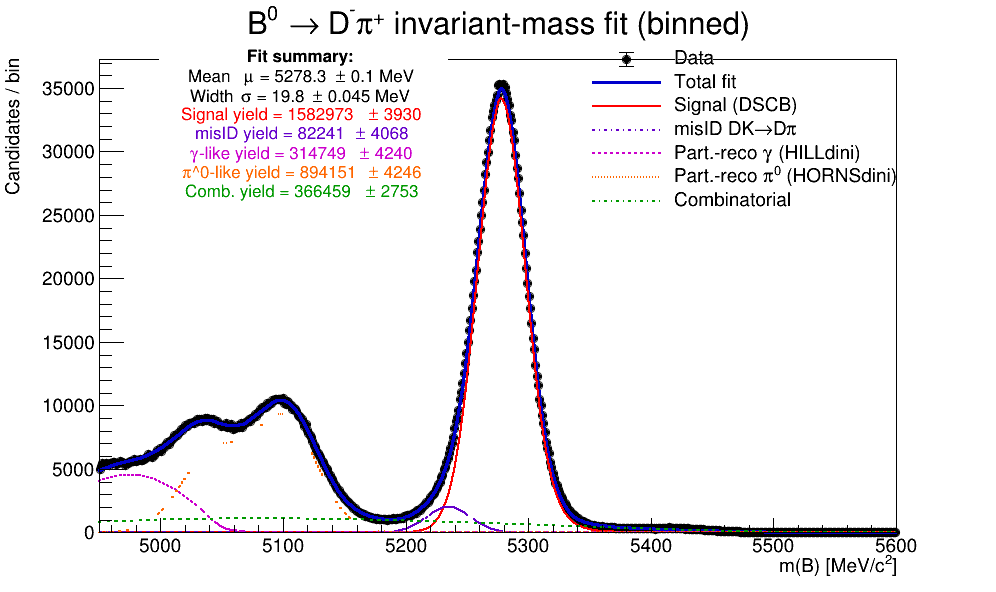


INFO:Minimization --  The following expressions will be evaluated in cache-and-track mode: (sigL,sigR,BKG_comb)
PID1430979/RooRealMPFE::nll_pdf_pre_dh_cb428f0_MPFE3[ arg=nll_pdf_pre_dh_GOF3 vars=(Ncomb,Nsig,aL,aR,c0,c1,c2,fLR,mu,nL,nR,sig) ]

PID1430979/RooRealMPFE::nll_pdf_pre_dh_cb428f0_MPFE3[ arg=nll_pdf_pre_dh_GOF3 vars=(Ncomb,Nsig,aL,aR,c0,c1,c2,fLR,mu,nL,nR,sig) ]

PID1430979/RooRealMPFE::nll_pdf_pre_dh_cb428f0_MPFE3[ arg=nll_pdf_pre_dh_GOF3 vars=(Ncomb,Nsig,aL,aR,c0,c1,c2,fLR,mu,nL,nR,sig) ]

PID1430979/RooRealMPFE::nll_pdf_pre_dh_cb428f0_MPFE3[ arg=nll_pdf_pre_dh_GOF3 vars=(Ncomb,Nsig,aL,aR,c0,c1,c2,fLR,mu,nL,nR,sig) ]

PID1430979/RooRealMPFE::nll_pdf_pre_dh_cb428f0_MPFE3[ arg=nll_pdf_pre_dh_GOF3 vars=(Ncomb,Nsig,aL,aR,c0,c1,c2,fLR,mu,nL,nR,sig) ]

PID1430979/RooRealMPFE::nll_pdf_pre_dh_cb428f0_MPFE3[ arg=nll_pdf_pre_dh_GOF3 vars=(Ncomb,Nsig,aL,aR,c0,c1,c2,fLR,mu,nL,nR,sig) ]

PID1430979/RooRealMPFE::nll_pdf_pre_dh_cb428f0_MPFE3[ arg=nll_pdf_pre_dh_GOF3 vars=(Ncomb,Nsig,aL,aR,

Info in <TCanvas::Print>: png file /tmp/fit_1762774440.png has been created



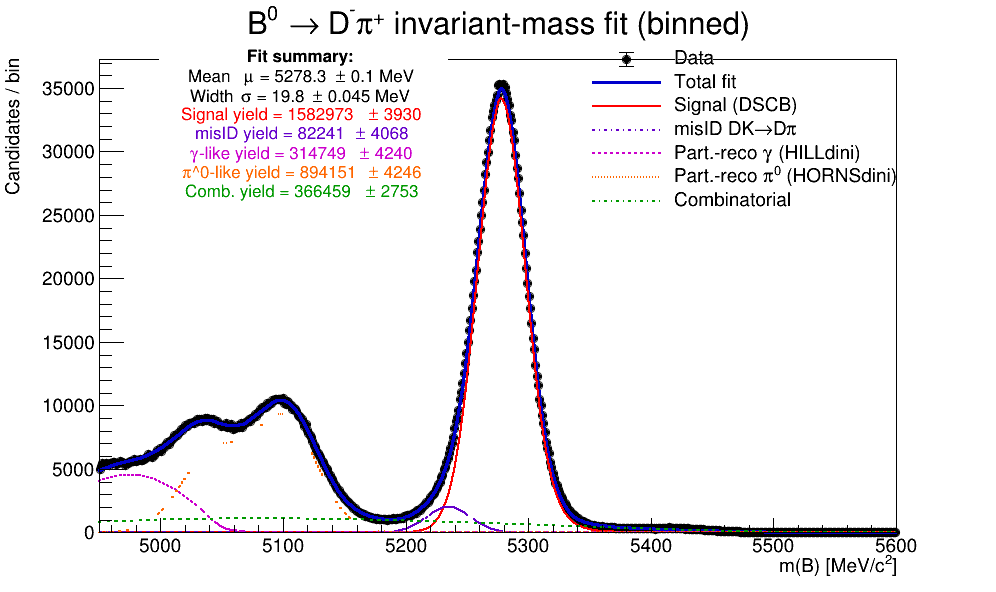

In [2]:
# -*- coding: utf-8 -*-
# Bd -> D- pi+ binned fit with:
#  - XS Bd2DPi 24c2 up/down tuples
#  - optional s24c4 lumi run selection (runNumber)
#  - XG cut: BDTGResponse_XGB_1 > 0.991
#  - HILL/HORNS + Cheby comb model (template-based)

import os, time
import numpy as np
import uproot
import ROOT
from ROOT import RooFit as RF
from IPython.display import Image as IPyImage, display as ipydisplay

# -----------------------------
# Config
# -----------------------------
FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c2_up_final.root",
]
assert all(os.path.exists(f) for f in FILES), "One or more FILES do not exist."

TREE_PATH  = "Tuple/DecayTree"

USE_SUBSET = False
SUBSET_N   = 300_000

# *** IMPORTANT SWITCH ***
# For your current 24c2 files, leave this False (no lumi cut).
# When you have the true s24c4 tuples, set to True and keep the run ranges below.
USE_S24C4_RUNS = False

NBINS      = 600            # finer binning for ~16 MeV core width
COMB_MODEL = "cheby"        # "cheby" or "expo"

D_MASS, D_WINDOW = 1869.65, 30.0
B_END_VCHI2DOF_MAX, D_END_VCHI2DOF_MAX = 7.0, 7.0
BACHELOR_PIDK_MAX = 0.0     # pion-like bachelor
M_PI, M_K = 139.57039, 493.677
mmin, mmax = 4950., 5600.

# s24c4 run ranges (for runNumber)
RUN_UP_MIN,   RUN_UP_MAX   = 308104, 308540
RUN_DOWN_MIN, RUN_DOWN_MAX = 307589, 308098

# XG (BDT) cut (from your optimisation)
XG_CUT    = 0.991
XG_BRANCH = "BDTGResponse_XGB_1"

# -----------------------------
# ROOT housekeeping
# -----------------------------
ROOT.gROOT.SetBatch(True)
ROOT.EnableImplicitMT()
base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs loaded:", hasattr(ROOT,"RooHILLdini"), hasattr(ROOT,"RooHORNSdini"))

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw): return it

# -----------------------------
# Build Dπ sample (run + XG + physics cuts)
# -----------------------------
vals_all = []

branches = [
    "lab0_MASS", "lab0_END_VCHI2DOF",
    "lab2_END_VCHI2DOF", "lab2_MASS",
    "lab1_PIDK",
    "runNumber",          # used for lumi selection
    XG_BRANCH,
]

need = SUBSET_N if USE_SUBSET else float("inf")
got  = 0
t0   = time.time()
print(f"\n[build] applying Bd->Dπ cuts, "
      f"{'WITH' if USE_S24C4_RUNS else 'WITHOUT'} s24c4 lumi, "
      f"XG > {XG_CUT:.3f}, and skimming...")

all_runs = []

for arrays in tqdm(
    uproot.iterate([f"{fp}:{TREE_PATH}" for fp in FILES],
                   expressions=branches, step_size="60 MB",
                   library="np", allow_missing=False),
    desc="Reading tuples"
):
    mB   = arrays["lab0_MASS"]
    bchi = arrays["lab0_END_VCHI2DOF"]
    dchi = arrays["lab2_END_VCHI2DOF"]
    mD   = arrays["lab2_MASS"]
    pidk = arrays["lab1_PIDK"]
    runs = arrays["runNumber"]
    xg   = arrays[XG_BRANCH]

    finite = (
        np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
        np.isfinite(mD) & np.isfinite(pidk) &
        np.isfinite(runs) & np.isfinite(xg)
    )

    mB   = mB[finite]
    bchi = bchi[finite]
    dchi = dchi[finite]
    mD   = mD[finite]
    pidk = pidk[finite]
    runs = runs[finite]
    xg   = xg[finite]

    all_runs.append(runs)

    # lumi selection (optional)
    if USE_S24C4_RUNS:
        run_sel = (
            ((runs >= RUN_UP_MIN)   & (runs <= RUN_UP_MAX)) |
            ((runs >= RUN_DOWN_MIN) & (runs <= RUN_DOWN_MAX))
        )
    else:
        run_sel = np.ones_like(runs, dtype=bool)

    sel = (
        run_sel &
        (xg > XG_CUT) &
        (pidk < BACHELOR_PIDK_MAX) &
        (bchi < B_END_VCHI2DOF_MAX) &
        (dchi < D_END_VCHI2DOF_MAX) &
        (np.abs(mD - D_MASS) < D_WINDOW)
    )

    v = mB[sel]

    if USE_SUBSET and got < need:
        v = v[: int(max(0, need - got))]
    vals_all.append(v)
    got += v.size
    if got >= need:
        break

# print run range info
if all_runs:
    rr = np.concatenate(all_runs)
    print(f"[runs] runNumber range (after basic finite): {rr.min():.0f} – {rr.max():.0f}")

vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
vals = vals[(vals > mmin) & (vals < mmax)]
print(f"[build] done in {time.time()-t0:.1f}s — kept {vals.size} events after all cuts")

if vals.size == 0:
    raise RuntimeError(
        "No events after cuts/subset.\n"
        "If USE_S24C4_RUNS=True, your 24c2 files probably do not contain runs "
        "307589–308540 in 'runNumber'. Try setting USE_S24C4_RUNS=False,\n"
        "or point FILES to the actual s24c4 tuples once you have them."
    )

# -----------------------------
# Make binned RooDataHist
# -----------------------------
m  = ROOT.RooRealVar("m","m(B) [MeV/c^{2}]", mmin, mmax)

# Seed comb slope sign from a simple low-mass regression
side = vals[(vals > 4950) & (vals < 5150)]
if side.size > 10:
    hist_side, edges = np.histogram(side, bins=40, range=(4950,5150))
    xmid = 0.5*(edges[1:]+edges[:-1])
    coef = np.polyfit(xmid, hist_side, 1)[0]  # slope sign
else:
    coef = 0.0

hist, edges = np.histogram(vals, bins=NBINS, range=(mmin,mmax))
dhist = ROOT.TH1D("h","h", NBINS, mmin, mmax)
for i, y in enumerate(hist, start=1):
    dhist.SetBinContent(i, float(y))
dh = ROOT.RooDataHist("dh","binned Dpi", ROOT.RooArgList(m), dhist)

# -----------------------------
# Seeds for mu, sigma
# -----------------------------
focus = vals[(vals>5230)&(vals<5330)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5230,5330))
    edges = np.linspace(5230,5330,81)
    xmid  = 0.5*(edges[1:]+edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals[(vals>mu0-40)&(vals<mu0+40)]
sig0 = np.std(selp) if selp.size>1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

# -----------------------------
# Physics model (your template)
# -----------------------------
mu  = ROOT.RooRealVar("mu","mean", mu0, mu0-30., mu0+30.)
sig = ROOT.RooRealVar("sig","sigma", sig0, 8., 30.)

# signal DSCB
aL,nL = ROOT.RooRealVar("aL","aL",1.6,0.5,5), ROOT.RooRealVar("nL","nL",4,1,20)
sigL  = ROOT.RooCBShape("sigL","left CB",  m, mu, sig, aL, nL)
aR,nR = ROOT.RooRealVar("aR","aR",-2.0,-6,-0.5), ROOT.RooRealVar("nR","nR",3,1,20)
sigR  = ROOT.RooCBShape("sigR","right CB", m, mu, sig, aR, nR)
fLR   = ROOT.RooRealVar("fLR","frac left",0.5,0.1,0.9)
SIG   = ROOT.RooAddPdf("SIG","DSCB", ROOT.RooArgList(sigL, sigR), ROOT.RooArgList(fLR))

# mis-ID DK->Dpi
dMis   = ROOT.RooRealVar("dMis","DK->Dpi shift",45,35,55)
mu_mis = ROOT.RooFormulaVar("mu_mis","@0-@1", ROOT.RooArgList(mu,dMis))
sig_mis= ROOT.RooRealVar("sig_mis","misID width",max(14.0,min(20.0,sig0+2.)),12,28)
MIS    = ROOT.RooGaussian("MIS","misID DK->Dpi", m, mu_mis, sig_mis)

# partial reco HILL / HORNS
h_a  = ROOT.RooRealVar("h_a","HILL a",4950,4900,5150)
dHb  = ROOT.RooRealVar("dHb","Δ_HILL",140,70,240)
h_b  = ROOT.RooFormulaVar("h_b","@0-@1", ROOT.RooArgList(mu,dHb))
h_c  = ROOT.RooRealVar("h_csi","HILL csi",0.45,0,1)
h_sh = ROOT.RooRealVar("h_shift","HILL shift",0.0)
h_sg = ROOT.RooRealVar("h_sigma","HILL sigma",22,8,40)
h_rs = ROOT.RooRealVar("h_rs","HILL ratio_sigma",2.0,1.2,3.5)
h_fs = ROOT.RooRealVar("h_fs","HILL fraction_sigma",0.5,0.2,0.8)
BKG_g = ROOT.RooHILLdini("BKG_g","gamma-like", m, h_a,h_b,h_c,h_sh,h_sg,h_rs,h_fs)

r_a  = ROOT.RooRealVar("r_a","HORNS a",5020,4950,5200)
dRb  = ROOT.RooRealVar("dRb","Δ_HORNS",90,40,180)
r_b  = ROOT.RooFormulaVar("r_b","@0-@1", ROOT.RooArgList(mu,dRb))
r_c  = ROOT.RooRealVar("r_csi","HORNS csi",0.30,0,1)
r_sh = ROOT.RooRealVar("r_shift","HORNS shift",0.0)
r_sg = ROOT.RooRealVar("r_sigma","HORNS sigma",24,8,45)
r_rs = ROOT.RooRealVar("r_rs","HORNS ratio_sigma",2.0,1.2,3.5)
r_fs = ROOT.RooRealVar("r_fs","HORNS fraction_sigma",0.5,0.2,0.8)
BKG_pi = ROOT.RooHORNSdini("BKG_pi","pi-like", m, r_a,r_b,r_c,r_sh,r_sg,r_rs,r_fs)

# comb
if COMB_MODEL == "expo":
    b = ROOT.RooRealVar("b_slope","expo slope",
                        -1e-3 if coef<=0 else 1e-3, -5e-3, 5e-3)
    BKG_comb = ROOT.RooExponential("BKG_comb","comb", m, b)
else:
    c0 = ROOT.RooRealVar("c0","c0", 0.0, -1.0, 1.0)
    c1 = ROOT.RooRealVar("c1","c1", -0.10 if coef<=0 else 0.10, -1.0, 1.0)
    c2 = ROOT.RooRealVar("c2","c2", 0.0, -1.0, 1.0)
    BKG_comb = ROOT.RooChebychev("BKG_comb","comb", m, ROOT.RooArgList(c0,c1,c2))

# yields
Ntot  = float(np.sum(hist))
Nsig  = ROOT.RooRealVar("Nsig","signal yield", 0.15*Ntot, 0.0, 2.0*Ntot)
Nmis  = ROOT.RooRealVar("Nmis","misID yield",  0.01*Ntot, 0.0, 0.25*Ntot)
Ng    = ROOT.RooRealVar("Ng",  "gamma yield",  0.04*Ntot, 0.0, 1.0*Ntot)
Npi   = ROOT.RooRealVar("Npi", "pi0 yield",    0.01*Ntot, 0.0, 1.0*Ntot)
Ncomb = ROOT.RooRealVar("Ncomb","comb yield",  0.75*Ntot, 0.0, 2.0*Ntot)

# sideband constraints
m.setRange("LSB", 4950, 5150)
m.setRange("RSB", 5450, 5600)

print("\n[sidebands] fitting comb-only in LSB+RSB...")
_ = BKG_comb.fitTo(dh, RF.Range("LSB,RSB"), RF.PrintLevel(-1))

constraints = ROOT.RooArgSet()

def _attach_shape_constraint(param, rel=0.30, floor=1e-4):
    val = param.getVal()
    sigma = max(rel*abs(val), floor)
    g = ROOT.RooGaussian(f"g_{param.GetName()}","comb prior",
                         param, RF.RooConst(val), RF.RooConst(sigma))
    constraints.addOwned(g)

if COMB_MODEL == "expo":
    _attach_shape_constraint(b, rel=0.30, floor=1e-5)
else:
    for p in (c0,c1,c2):
        _attach_shape_constraint(p, rel=0.30, floor=1e-4)

mu_Ng,  sig_Ng  = 0.03*Ntot, max(1.0, 0.03*Ntot)
mu_Npi, sig_Npi = 0.01*Ntot, max(1.0, 0.01*Ntot)
gNg  = ROOT.RooGaussian("gNg","weak prior Ng",  Ng,  RF.RooConst(mu_Ng),  RF.RooConst(sig_Ng))
gNpi = ROOT.RooGaussian("gNpi","weak prior Npi", Npi, RF.RooConst(mu_Npi), RF.RooConst(sig_Npi))
constraints.addOwned(gNg); constraints.addOwned(gNpi)

# prefit: signal+comb, tails frozen
for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(True)

pdf_pre = ROOT.RooAddPdf("pdf_pre","pre", ROOT.RooArgList(SIG,BKG_comb),
                         ROOT.RooArgList(Nsig,Ncomb))
print("\n[prefit] signal+comb (tails frozen)...")
_ = pdf_pre.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Minimizer("Minuit2","Migrad"),
    RF.PrintLevel(-1),
)

for v_ in (aL,nL,aR,nR,fLR):
    v_.setConstant(False)

# full fit
pdf = ROOT.RooAddPdf("pdf","Dpi model",
                     ROOT.RooArgList(SIG, MIS, BKG_g, BKG_pi, BKG_comb),
                     ROOT.RooArgList(Nsig, Nmis, Ng, Npi, Ncomb))

print("\n[fit] final binned extended likelihood, NBINS =", NBINS)
tfit = time.time()
fitres = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Migrad"),
    RF.Save(True),
    RF.PrintLevel(-1),
)
_ = pdf.fitTo(
    dh,
    RF.Extended(True),
    RF.ExternalConstraints(constraints),
    RF.NumCPU(8),
    RF.Offset(True),
    RF.Strategy(2),
    RF.Minimizer("Minuit2","Hesse"),
    RF.Save(True),
    RF.PrintLevel(-1),
)

print(f"[fit] time: {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")

# -----------------------------
# Plot
# -----------------------------
frame = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} invariant-mass fit (binned)"))
dh.plotOn(frame, RF.Name("data"))
pdf.plotOn(frame, RF.LineColor(ROOT.kBlue+1), RF.LineWidth(3), RF.Name("total"))
pdf.plotOn(frame, RF.Components("SIG"),      RF.LineColor(ROOT.kRed),        RF.LineWidth(2), RF.Name("sig_line"))
pdf.plotOn(frame, RF.Components("MIS"),      RF.LineColor(ROOT.kViolet+2),   RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("mis_line"))
pdf.plotOn(frame, RF.Components("BKG_g"),    RF.LineColor(ROOT.kMagenta+1),  RF.LineStyle(ROOT.kDashed),     RF.LineWidth(2), RF.Name("hill_line"))
pdf.plotOn(frame, RF.Components("BKG_pi"),   RF.LineColor(ROOT.kOrange+7),   RF.LineStyle(ROOT.kDotted),     RF.LineWidth(2), RF.Name("horn_line"))
pdf.plotOn(frame, RF.Components("BKG_comb"), RF.LineColor(ROOT.kGreen+2),    RF.LineStyle(ROOT.kDashDotted), RF.LineWidth(2), RF.Name("comb_line"))

c = ROOT.TCanvas(f"c_{int(time.time())}","DpiFit",1000,620)
frame.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame.GetYaxis().SetTitle("Candidates / bin")
frame.Draw()

leg = ROOT.TLegend(0.58, 0.64, 0.97, 0.92)
leg.SetFillStyle(0); leg.SetBorderSize(0); leg.SetTextFont(42); leg.SetTextSize(0.035)
leg.AddEntry(frame.findObject("data"),  "Data",                 "pe")
leg.AddEntry(frame.findObject("total"), "Total fit",            "l")
leg.AddEntry(frame.findObject("sig_line"),   "Signal (DSCB)",               "l")
leg.AddEntry(frame.findObject("mis_line"),   "misID DK#rightarrowD#pi",     "l")
leg.AddEntry(frame.findObject("hill_line"),  "Part.-reco #gamma (HILLdini)","l")
leg.AddEntry(frame.findObject("horn_line"),  "Part.-reco #pi^{0} (HORNSdini)","l")
leg.AddEntry(frame.findObject("comb_line"),  "Combinatorial",               "l")
leg.Draw()

box = ROOT.TPaveText(0.16, 0.66, 0.45, 0.92, "NDC")
box.SetFillColor(0); box.SetBorderSize(0); box.SetTextFont(42); box.SetTextSize(0.032)
box.AddText("#bf{Fit summary:}")
box.AddText(f"Mean  #mu = {mu.getValV():.1f} #pm {mu.getError():.1f} MeV")
box.AddText(f"Width #sigma = {sig.getValV():.1f} #pm {sig.getError():.3f} MeV")
t = box.AddText(f"Signal yield = {Nsig.getValV():.0f} #pm {Nsig.getError():.0f}"); t.SetTextColor(ROOT.kRed)
t = box.AddText(f"misID yield = {Nmis.getValV():.0f} #pm {Nmis.getError():.0f}"); t.SetTextColor(ROOT.kViolet+2)
t = box.AddText(f"#gamma-like yield = {Ng.getValV():.0f} #pm {Ng.getError():.0f}"); t.SetTextColor(ROOT.kMagenta+1)
t = box.AddText(f"#pi^{0}-like yield = {Npi.getValV():.0f} #pm {Npi.getError():.0f}"); t.SetTextColor(ROOT.kOrange+7)
t = box.AddText(f"Comb. yield = {Ncomb.getValV():.0f} #pm {Ncomb.getError():.0f}"); t.SetTextColor(ROOT.kGreen+2)
box.Draw()

c.Modified(); c.Update(); ROOT.gSystem.ProcessEvents()
tmp_png = f"/tmp/fit_{int(time.time())}.png"
c.SaveAs(tmp_png)
try:
    ipydisplay(IPyImage(filename=tmp_png))
except Exception:
    print(f"Saved plot to {tmp_png}")


In [3]:
print(f"[build] kept {vals.size} events after all cuts")
print(f"[build] hist integral = {int(Ntot)}")

# just to see what runs survive:
rr = np.concatenate(all_runs)
print(f"[runs] min runNumber in file = {rr.min():.0f}")
print(f"[runs] max runNumber in file = {rr.max():.0f}")

# how many events pass the lumi selection?
if USE_S24C4_RUNS:
    lumi_mask = (
        ((rr >= RUN_UP_MIN)   & (rr <= RUN_UP_MAX)) |
        ((rr >= RUN_DOWN_MIN) & (rr <= RUN_DOWN_MAX))
    )
    print(f"[runs] fraction of events inside lumi window = {lumi_mask.mean():.3f}")


[build] kept 3241282 events after all cuts
[build] hist integral = 3241282
[runs] min runNumber in file = 297132
[runs] max runNumber in file = 304604

